In [53]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
from dotenv import load_dotenv
load_dotenv()
import os

In [54]:
def pdf_loader(file_path):
    loader = DirectoryLoader(
        file_path, glob="*.pdf", loader_cls=PyPDFLoader
    )
    documents = loader.load()
    
    return documents

def filter_contents(documents):
    contents = []
    for doc in documents:
        content = doc.page_content
        source = doc.metadata.get("source")
        contents.append(
            Document(
                page_content=content,
                metadata={"source": source}
            )
        )
    
    return contents

def text_split(contents):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=700,
        chunk_overlap=30
    )
    chunks = text_splitter.split_documents(contents)

    return chunks

In [55]:
def text_embeddings():
    embeddings=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
                                  #this model return 384 dimensions
    
    return embeddings

In [4]:
file_path = '../data/'
documents=pdf_loader(file_path)
contents = filter_contents(documents)
chunks = text_split(contents)


fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Type': '/Font', '/Encoding': '/WinAnsiEncoding', '/BaseFont': '/PKNADH+Berkeley-BookItalic', '/FirstChar': 32, '/LastChar': 111, '/Subtype': '/Type1', '/FontDescriptor': IndirectObject(8788, 0, 2598715381408), '/Widths': [241, 241, 352, 481, 481, 667, 778, 204, 315, 315, 500, 481, 241, 333, 241, 278, 481, 481, 481, 481, 481, 481, 481, 481, 481, 481, 241, 241, 481, 481, 481, 352, 800, 593, 519, 611, 685, 537, 519, 667, 685, 296, 296, 611, 500, 796, 685, 685, 519, 667, 556, 463, 556, 685, 593, 870, 593, 519, 556, 315, 278, 315, 481, 500, 241, 463, 444, 370, 463, 389, 259, 407, 463, 241, 241, 444, 241, 722, 481, 426]}, but is not installed. Consider installing fontTools if you encounter encoding problems.
fontTools is required to fully parse the encoding of a CFF Type1 font in font dictionary {'/Type': '/Font', '/Encoding': '/WinAnsiEncoding', '/BaseFont': '/PKNAFK+Berkeley-Bold', '/FirstChar': 32,

In [56]:
embeddings = text_embeddings()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1463.71it/s]


In [57]:
pc_api_key = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key=pc_api_key)

In [7]:
index_name = "medical-chatbot"
if not pc.has_index(index_name):
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )

index = pc.Index(index_name)

In [11]:
vectorstore = PineconeVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    index_name=index_name
)

In [96]:
index_name = "medical-chatbot"
vectorsearch = PineconeVectorStore.from_existing_index(
    embedding=embeddings,
    index_name=index_name
)

retriever = vectorsearch.as_retriever(search_type="similarity",  search_kwargs={"k": 3})
retriever.invoke("What is Acne?")



[Document(id='a5605ba9-118c-47ff-810b-468f0574048b', metadata={'source': '..\\data\\Medical_book.pdf'}, page_content='acne.\nPurpose\nDifferent types of antiacne drugs are used for differ-\nent purposes. For example, lotions, soaps, gels, and\ncreams containing benzoyl peroxide or tretinoin may be\nused to clear up mild to moderately severe acne.\nIsotretinoin (Accutane) is prescribed only for very\nsevere, disfiguring acne.\nAcne is a skin condition that occurs when pores or\nhair follicles become blocked. This allows a waxy\nmaterial, sebum, to collect inside the pores or follicles.\nNormally, sebum flows out onto the skin and hair to\nform a protective coating, but when it cannot get out,\nsmall swellings develop on the skin surface. Bacteria\nand dead skin cells can also collect that can cause'),
 Document(id='3b2c01e6-3cf1-4743-92be-2c70994308ec', metadata={'source': '..\\data\\Medical_book.pdf'}, page_content='pores of the skin become clogged with oil, dead skin\ncells, and bacte

In [ ]:
import os
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, END
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain.schema import Document
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import operator
from dotenv import load_dotenv
load_dotenv()

True

In [106]:
memory = MemorySaver()

class BasicAgent(TypedDict):
    messages: Annotated[list, add_messages]
    documents: list[Document]
    # documents: Annotated[list[Document], operator.add] 
    on_topic: str
    question: str

def query_class(state: BasicAgent):
    query = state["messages"][-1].content
    
    message ="""You are a classifier that determines if a query is on medical 
                related topics or not. If query is on medical related topics, 
                respond with 'Yes', otherwise respond with 'No'."""
    
    prompt = [("system", message), 
              ("human", query)]
    
    llm = ChatOpenAI(model="gpt-4o",
                    api_key=os.environ.get("OPENAI_API_KEY")
        )
    result = llm.invoke(prompt)
    
    return {"messages": [result], 
            "on_topic": result.content.strip(),
            "question": query}

def topic_router(state: BasicAgent):
    on_topic = state["on_topic"]
    if on_topic.lower() == "yes":
        return "Yes"
    else:
        return "No"
    
def off_topic(state: BasicAgent):
    return {"messages": [HumanMessage(content="Sorry, I can only answer medical related queries.")]}
    
def on_topic_retriever(state: BasicAgent, retriever=retriever):
    question = state["question"]
    documents = retriever.invoke(question)
    
    return {"documents": documents}

def generator(state: BasicAgent):
    question = state["question"]
    # documents = state["documents"]
    documents = state.get("documents", [])
    if not documents:
        print("⚠️ Warning: No documents found in state context!")
    
    context = "\n".join([doc.page_content for doc in documents])
    
    message = f"""You are a medical chatbot that provides information based on the 
                  provided context. Answer the following question based on the context 
                  below. If the answer is not present in the context, respond with 
                  'I don't know'.
                  
                  Context: {context}
                  Question: {question}"""
    
    prompt = [("system", message)]
    
    llm = ChatOpenAI(model="gpt-4o",
                    api_key=os.environ.get("OPENAI_API_KEY")
        )
    result = llm.invoke(prompt)
    
    return {"messages": [result], "on_topic": result.content.strip(), "documents": documents}

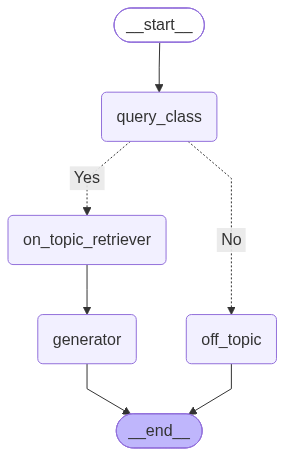

In [107]:
graph = StateGraph(BasicAgent)
graph.add_node("query_class", query_class)
graph.set_entry_point("query_class")
graph.add_node("off_topic", off_topic)
graph.add_node("on_topic_retriever", on_topic_retriever)
graph.add_node("generator", generator)
graph.add_conditional_edges("query_class", topic_router,
                            {"Yes": "on_topic_retriever", "No": "off_topic"})
graph.add_edge("off_topic", END)
graph.add_edge("on_topic_retriever", "generator")
graph.add_edge("generator", END)

app = graph.compile(checkpointer=memory)
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
    

In [108]:
response = app.invoke(
    {"messages": [HumanMessage(content="What is Acne?")]},
    config={"configurable": {"thread_id": "1"}} # Required for MemorySaver
)


print(response["messages"][-1].content)
# print(response["on_topic"])
# print(response['documents'])

Acne is a skin condition that occurs when pores or hair follicles become blocked. It involves the collection of a waxy material called sebum inside the pores or follicles, which normally forms a protective coating on the skin and hair. When sebum cannot get out, small swellings develop on the skin surface. Acne vulgaris, the medical term for common acne, is the most common skin disease affecting nearly 17 million people in the United States. It usually begins at puberty and worsens during adolescence.
